# 17_机器学习模型评估方法-召回率

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家来聊聊**机器学习模型评估方法-召回率**\~

### 召回率是干嘛的？

**召回率就是用来衡量模型有没有漏掉重要目标的比例。**

假如你在找丢了的小猫（正类），你找了100只猫，实际有20只是你家猫，模型帮你找回来其中15只。那么你就找回来 15 / 20 = **75%**，这就是**召回率**！

### 举个简单的例子：

| 猫编号 | 实际是你家的猫吗？ | 模型说是你家的猫吗？ |
|-|-|-|
| 1 | 是 | 是 |
| 2 | 是 | 是 |
| 3 | 是 | 否 ❌ |
| 4 | 是 | 是 |
| 5 | 是 | 否 ❌ |
| ... | ... | ... |

假设总共有 10 只你家猫（正类），你模型只找对了其中 6 只（预测对的正类），那召回率就是：

👉 **召回率 = 6 / 10 = 60%**

你找回来了 60% 的丢猫，**虽然不一定找得很准，但找回来的猫尽量多。**

**召回率（Recall）是指在所有真实为正类的样本中，被模型正确识别为正类的比例。**

也就是说，它衡量的是你有没有把该找的目标都找出来了。

## 数学原理

### 四种分类结果（混淆矩阵）

在分类任务中，预测结果和真实标签可能组合成以下 4 种情况：

|  | **真实为正类** | **真实为负类** |
|-|-|-|
| **预测为正类** | TP（真阳性） | FP（假阳性） |
| **预测为负类** | FN（假阴性） | TN（真阴性） |

- **TP（True Positive）**：模型预测正类，实际也为正类
- **FN（False Negative）**：模型预测负类，但实际是正类 → **漏掉了目标！**
- **FP（False Positive）**：模型预测正类，实际是负类 → **错抓了无关的**
- **TN（True Negative）**：模型预测负类，实际也是负类

### 召回率公式


$$
\text{召回率} = \frac{TP}{TP + FN}
$$


即：


$$
>\text{召回率} = \frac{\text{预测对的正类}}{\text{实际所有的正类}}>
$$


意思就是，实际中应该被发现的正类样本中，模型到底发现了多少个。

### 举例推导公式

假设你在做肿瘤检测（正类 = 有肿瘤），你有以下检测结果：

- **检测正确地找出肿瘤的病人（TP）**：80人
- **漏掉了实际有肿瘤的人（FN）**：20人
- **所以，总共有肿瘤的病人**：100人（80 + 20）

召回率就是：


$$
\text{召回率} = \frac{80}{80 + 20} = 0.8 = 80\%
$$


说明你成功识别出了 80% 的有肿瘤病人。

## 召回率的作用和价值

召回率特别重要的场景是：**不能漏掉任何重要目标！**

### 常见场景

- **医学诊断（肿瘤检测）**：宁可误判一些没病的，也不能漏掉一个有病的。
- **垃圾邮件检测**：宁可多拦几个正常邮件，也不能放过一封垃圾邮件。
- **安检识别武器**：宁可误报普通物品，也不能漏掉危险品。

这种时候，**召回率越高越好**，宁可牺牲一点准确性，也要尽量“全找回来”。

## 召回率的评估流程

**步骤如下：**

1. **模型预测结果输出**：得到所有样本的预测标签（比如预测有没有肿瘤）。
2. **与真实标签对比，构造混淆矩阵**：统计出 TP、FN（召回率只用这两个）。
3. **计算公式**


$$
\text{Recall} = \frac{TP}{TP + FN}
$$


1. **多分类时怎么办？**

   - 可以对每一类都算召回率，叫**每类召回率（per-class recall）**
   - 再求个平均，叫**宏平均召回率（Macro Recall）**

## 完整案例

假设我们正在做**医疗疾病诊断**任务，预测某种罕见疾病的患者是否患病。数据集比较复杂，正负样本比例不平衡，正类（患病）样本较少。我们用机器学习模型预测患者是否患病，评估模型效果时，重点关注**召回率**，确保尽可能多地发现患病患者。

我们使用一个模拟数据集：

- 1000个样本
- 20个特征（数值型）
- 正类比例约5%（即50个患病患者，950个健康人）

### 实现思路

- 使用`scikit-learn`生成模拟数据
- 用`RandomForestClassifier`模型进行分类
- 评估指标包括准确率、精确率、召回率、F1分数
- 重点展示召回率计算及影响
- 绘制混淆矩阵和PR曲线（Precision-Recall曲线）直观表现
- 讲解每一步代码及分析结果

正类样本数（患病患者）：100
负类样本数（健康人）：1900

混淆矩阵
[[570   0]
 [  2  28]]

 分类报告
              precision    recall  f1-score   support

           0     0.9965    1.0000    0.9982       570
           1     1.0000    0.9333    0.9655        30

    accuracy                         0.9967       600
   macro avg     0.9983    0.9667    0.9819       600
weighted avg     0.9967    0.9967    0.9966       600

手动计算召回率: 0.9333


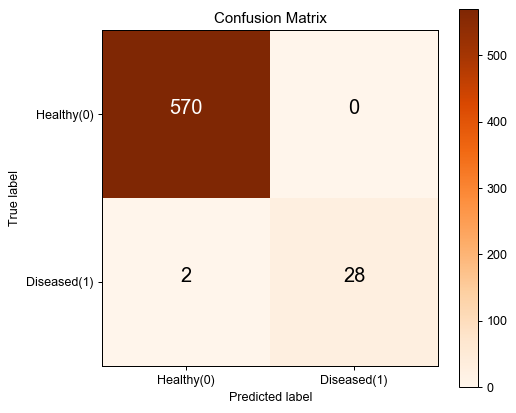

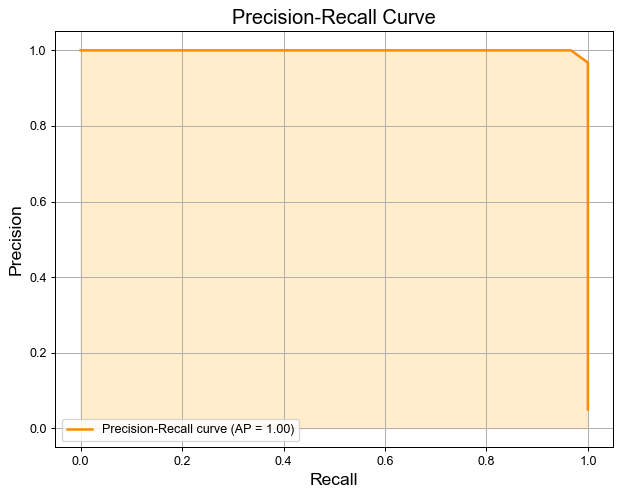

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             precision_recall_curve, average_precision_score)
from sklearn.model_selection import train_test_split

# Step 1: 生成不平衡的模拟数据
X, y = make_classification(n_samples=2000, n_features=20, n_informative=5, 
                           n_redundant=2, n_clusters_per_class=1,
                           weights=[0.95, 0.05], flip_y=0, random_state=42)

print(f"正类样本数（患病患者）：{sum(y==1)}")
print(f"负类样本数（健康人）：{sum(y==0)}")

# Step 2: 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Step 3: 训练随机森林模型
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 4: 预测测试集结果
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # 预测为正类的概率，用于绘制PR曲线

# Step 5: 计算各种评估指标
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

# 计算召回率
TP = cm[1, 1]
FN = cm[1, 0]
recall = TP / (TP + FN)

print("\n混淆矩阵")
print(cm)

print("\n 分类报告")
print(report)

print(f"手动计算召回率: {recall:.4f}")

# Step 6: 绘制混淆矩阵可视化
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Healthy(0)', 'Diseased(1)'])
plt.yticks(tick_marks, ['Healthy(0)', 'Diseased(1)'])

# 标注数字
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=16)

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()

# Step 7: 绘制Precision-Recall曲线
precision, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision, color='darkorange', lw=2,
         label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.fill_between(recall_vals, precision, alpha=0.2, color='orange')
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve', fontsize=16)
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

**步骤 1: 生成不平衡数据集**：使用`make_classification`创建一个带标签的二分类数据集，设置`weights=[0.95, 0.05]`来制造严重类别不平衡（5%的正类），这模拟了现实中疾病样本往往少于健康样本的情况。

**步骤 2: 划分训练和测试集**：使用`train_test_split`将数据分成70%训练，30%测试，参数`stratify=y`确保训练集和测试集中的正负样本比例保持一致。

**步骤 3: 训练随机森林模型**：使用`RandomForestClassifier`，较为稳健且适合处理复杂非线性数据，训练模型，拟合训练集数据。

**步骤 4: 预测结果**：预测测试集标签：`y_pred`，获取正类概率：`y_proba`，后续绘制PR曲线用。

**步骤 5: 计算指标和混淆矩阵**：混淆矩阵展示四类情况，重点看TP和FN，使用`classification_report`打印详细指标，包括召回率、精确率、F1等，手动计算召回率，验证一致性。

**步骤 6: 混淆矩阵可视化**：在每个格子中显示数字，方便直观理解分类正确/错误的数量。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

**步骤 7: Precision-Recall曲线绘制**：PR曲线适合不平衡数据，展示阈值变化时精确率和召回率的关系，曲线下面积（AP）衡量整体表现，越接近1越好，从图中可以直观发现，召回率提升时，精确率如何变化。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

## 分析召回率的优缺点

**优点：**

- 强调“漏掉率”，尤其适合“漏一例可能后果严重”的应用场景
- 简单直观，能快速告诉你模型有没有把该发现的正类样本找出来
- 与精确率结合使用，可以更全面评估模型性能（F1分数）
- 在不平衡数据集中，召回率比准确率更有指导意义，因为准确率可能因为负类数量太多而失真

**缺点：**

- 只关注是否找回所有正样本，不关心“找出来的有多少是错的”，忽略了假阳性（FP）
- 如果只追求召回率，模型容易“放水”，大量预测为正，导致假阳性暴增，降低精确率
- 不适合对精度要求极高的场景，误报代价较大时单独看召回率有风险
- 无法反映模型对负类样本的分类能力，易导致评估片面

## 召回率何时是优选指标？

召回率作为评估指标，在以下场景中尤其重要：

- **医疗诊断中漏诊不可接受**：如癌症筛查，宁可多检查几次也不能漏掉患者
- **安检和安全检测**：不能漏掉潜在危险品，误报可容忍
- **欺诈检测**：尽可能找出所有欺诈交易，虽然会带来一些误报，但保障安全
- **信息检索和推荐系统**：确保用户获得尽可能多的相关结果，减少遗漏

总的来说，当“漏检成本远高于误检成本”时，召回率是首选评估标准。

## 总结

召回率是机器学习模型评估中不可或缺的指标，尤其在高风险漏检场景中具有无可替代的价值。然而，必须结合其他指标（如精确率、F1分数）综合考量。